# 04 — MOSFET Selection

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Rank the candidate MOSFETs in `data/mosfets.csv` by the FET-dependent loss at the Objective 1 point (5 V / 3 A input, boost to 12 V), with every datasheet value evaluated at the gate voltage the LM5176 actually delivers there.

**Design basis (V1):** hard-switched 4-switch buck-boost, the same part in all four positions, f_sw = 100 kHz, 47 µH Würth 7443634700 (notebook 03). In boost mode QH1 is held on, QL2 hard-switches and QH2 is the synchronous switch; I_L,avg = I_in = 3 A regardless of efficiency. Part data is transcribed from the datasheet tables in `datasheets/mosfets/` (revision per row in `Datasheet_Rev`); values read by eye from datasheet *figures* are kept apart in `data/mosfet_figure_reads.csv`.

**Key result — decision:** the V1 board uses **BSC0902NSI** with BIAS tied to VOUT (case A). There its FET-dependent loss is 135.6 mW, #4 of 16 ranked parts: 24.0 mW (0.16 % of the 15 W input) above the best checked part and 14.1 mW above **BSZ0501NSI**. BSZ0501NSI (30 V, integrated Schottky-like diode) is #1 or #2 in both gate-drive cases and under every sensitivity variant tried, and is recorded as the V2 candidate. It costs $1.49 more per board (4 FETs) at 50-board DigiKey pricing, $1.71 at JLCPCB. BSZ031NE2LS5 is #1 in case A but is a 25 V part, 86 % of its rating at the 21.5 V USB PD maximum, so it is for the output side only. A 40 V input-side part costs nothing at this point, because the input side only conducts in boost mode; buck-mode losses are not modeled yet. BSC0902NSI is 5 mW better than the similar BSC0902NS, at about the same price. V1 was meant to use a 40 V part; the draft part table listed BSC0902NS as 40 V, but both BSC0902NS and the built BSC0902NSI are 30 V (see Final Conclusions). (Earlier versions of this notebook named BSC0902NS as the V1 part and ranked parts from that unchecked table, using a three-term model with 10 V gate data.)

**See also:** 03 (inductor selection; uses the same FET row), `data/README.md` (mosfets.csv conventions), `datasheets/controllers/lm5176.pdf` (TI SNVSAI1D: VCC regulator, gate drivers, boost-mode loss equations).

## Operating point and gate drive

The LM5176 powers all four gate drivers from VCC. With BIAS = 0 V, VCC regulates at **7.35 V typ (6.95–7.88 V)**; for VIN below that target VCC *tracks VIN* (SNVSAI1D Electrical Characteristics and Figure 6-4). BIAS takes over the regulator input when it is above the 8 V switchover, e.g. when tied to VOUT = 12 V. So at the 5 V corner the gate voltage depends on how BIAS is wired. **The V1 board ties BIAS to VOUT** (designer, 2026-09-14; the schematic is not in this repository), so case A is the V1 basis. Case B is kept as the alternative wiring:

| Case | BIAS | Gate voltage V_drv | Gate charge drawn from |
|---|---|---|---|
| **A (V1)** | tied to VOUT (12 V) | VCC = 7.35 V (typ) | 12 V output (VCC is a linear regulator) |
| **B** | unused | VIN − R_OUT(VCC),max · I_VCC, per part: R_OUT(VCC) = 16 Ω max, I_VCC = 2·Q_g·f_sw + 2 mA | 5 V input |

Assumptions: in case B the VIN pin sits at the USB voltage (no series diode). The high-side drivers get VCC less the bootstrap-diode drop, which the datasheet table does not give, so it is not modeled.

In [1]:
import sys; sys.path.insert(0, '..')   # repo root: constants.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constants as cfg
from constants import IC_LM5176 as IC

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

# --- Operating point: Objective 1, source-limited 5 V / 3 A input, boost ---
V_IN = cfg.USB.V_MIN                    # 5 V
I_IN = cfg.USB.I_MAX_STANDARD           # 3 A
V_OUT = cfg.FAN.V_NOMINAL               # 12 V
F_SW = cfg.DESIGN.F_SW_HZ               # 100 kHz
V_IN_PD_MAX = cfg.USB.V_MAX * (1 + cfg.USB.V_PD_NEW_TOL) + cfg.USB.V_PD_VALID_ADD   # 21.5 V: USB PD spec max on a 20 V contract
V_IN_MAX = cfg.USB.V_MAX * (1 + cfg.USB.V_TOLERANCE)                                # 22 V: project design margin

ind = pd.read_csv('../data/inductors.csv', dtype={'Part_Number': str}).set_index('Part_Number').loc[cfg.ACTIVE_IND_ID]
L = ind['Inductance_uH'] * 1e-6

D = 1 - V_IN / V_OUT                    # boost duty
I_L = I_IN                              # boost: I_L,avg = I_in
dI = V_IN * D / (L * F_SW)
I_PK, I_VAL = I_L + dI / 2, I_L - dI / 2
I_RMS = np.sqrt(I_L**2 + dI**2 / 12)

print(f"Inductor {cfg.ACTIVE_IND_ID}: L = {L*1e6:.0f} µH")
print(f"V_in = {V_IN:.0f} V, I_in = {I_IN:.0f} A, V_out = {V_OUT:.0f} V, f_sw = {F_SW/1e3:.0f} kHz")
print(f"D = {D:.3f} | I_L avg = {I_L:.2f} A, ripple = {dI:.3f} A pk-pk, peak = {I_PK:.3f} A, valley = {I_VAL:.3f} A, rms = {I_RMS:.3f} A")

Inductor 7443634700: L = 47 µH
V_in = 5 V, I_in = 3 A, V_out = 12 V, f_sw = 100 kHz
D = 0.583 | I_L avg = 3.00 A, ripple = 0.621 A pk-pk, peak = 3.310 A, valley = 2.690 A, rms = 3.005 A


## Evaluating R_DS(on) and Q_g at the drive voltage

Datasheet tables give R_DS(on) and Q_g at 4.5 V and 10 V; neither is the drive voltage (7.35 V or ≈4.9 V).

- **R_DS(on):** R(V) = R₀ + K / (V − V_th) — channel resistance falls as 1/(V_GS − V_th), on top of a fixed part (package, drift region). R₀ and K are fitted through the two typical table values, with V_th = typical threshold, or the midpoint of min/max where no typical is given. Used only *between* its two anchors, never extrapolated: a part characterized only at 6 V and 10 V has no value at 4.9 V.
- **Q_g:** linear between the two table values. Above the Miller plateau the gate-charge curve is a straight line (e.g. BSZ0902NS Diagram 14), so this holds provided the lower anchor is above the plateau, which is checked.

The fit's shape is checked below against the R_DS(on)–V_GS curves of three parts from three manufacturers (figure reads in `data/mosfet_figure_reads.csv`, ±0.05–0.1 mΩ reading accuracy). For this check the fit is anchored at the *figure's own* 4.5 V and 10 V points, so only the model shape is being tested.

In [2]:
fets = pd.read_csv('../data/mosfets.csv').set_index('Part_Number')
figs = pd.read_csv('../data/mosfet_figure_reads.csv')

def fig_read(pn, qty, vgs=None):
    # Value read from a datasheet figure (data/mosfet_figure_reads.csv), NaN if none
    m = (figs['Part_Number'] == pn) & (figs['Quantity'] == qty)
    if vgs is not None:
        m &= np.isclose(figs['VGS_V'], vgs)
    return float(figs.loc[m, 'Value'].iloc[0]) if m.any() else np.nan

def vth_ref(m):
    return m['VGS_th_Typ(V)'] if pd.notna(m['VGS_th_Typ(V)']) else 0.5 * (m['VGS_th_Min(V)'] + m['VGS_th_Max(V)'])

def fit_rdson(p1, p2, vt):
    # R(V) = R0 + K/(V - Vt) through two (V, R) points
    (v1, r1), (v2, r2) = p1, p2
    k = (r1 - r2) / (1 / (v1 - vt) - 1 / (v2 - vt))
    return r2 - k / (v2 - vt), k

def rdson_anchors(m):
    pts = [(4.5, m['RDSon_4.5V_Typ(mOhm)']), (m['RDSon_Alt_VGS(V)'], m['RDSon_Alt_Typ(mOhm)']), (10.0, m['RDSon_10V_Typ(mOhm)'])]
    return sorted((v, r) for v, r in pts if pd.notna(v) and pd.notna(r))

def rdson_at(pn, v):
    # Typical R_DS(on) in ohm at V_GS = v (25 °C); NaN outside the tabulated V_GS range
    m = fets.loc[pn]
    pts = rdson_anchors(m)
    if pd.isna(v) or len(pts) < 2 or not (pts[0][0] <= v <= pts[-1][0]):
        return np.nan
    r0, k = fit_rdson(pts[0], pts[-1], vth_ref(m))
    return (r0 + k / (v - vth_ref(m))) * 1e-3

def vplateau(pn, m):
    return m['Vplateau_Typ(V)'] if pd.notna(m['Vplateau_Typ(V)']) else fig_read(pn, 'Vplateau')

def qg_anchors(pn, m):
    pts = [(4.5, m['Qg_4.5V_Typ(nC)']), (10.0, m['Qg_10V_Typ(nC)']), (m['Qg_Alt_VGS(V)'], m['Qg_Alt_Typ(nC)'])]
    pts = [(v, q) for v, q in pts if pd.notna(v) and pd.notna(q)]
    if len(pts) < 2:   # fewer than two table points: use the figure reads, if any
        fr = figs[(figs['Part_Number'] == pn) & (figs['Quantity'] == 'Qg')]
        pts = [(r.VGS_V, r.Value) for r in fr.itertuples()] or pts
    return sorted(pts)

def qg_at(pn, v):
    # Typical total gate charge in C at V_GS = v; NaN outside the anchors or if an anchor is on the plateau
    m = fets.loc[pn]
    pts = qg_anchors(pn, m)
    if pd.isna(v) or len(pts) < 2 or not (pts[0][0] <= v <= pts[-1][0]) or pts[0][0] <= vplateau(pn, m):
        return np.nan
    (v1, q1), (v2, q2) = pts[0], pts[-1]
    return (q1 + (q2 - q1) * (v - v1) / (v2 - v1)) * 1e-9

# --- Validation of the R_DS(on)(V_GS) shape against datasheet curves ---
val_rows = []
for pn in ['CSD17577Q5A', 'AON6512', 'BSZ0902NS']:
    rd = figs[(figs['Part_Number'] == pn) & (figs['Quantity'] == 'RDSon')].set_index('VGS_V')['Value']
    r0, k = fit_rdson((4.5, rd[4.5]), (10.0, rd[10.0]), vth_ref(fets.loc[pn]))
    for v, r_fig in rd.items():
        if v in (4.5, 10.0):
            continue
        r_fit = r0 + k / (v - vth_ref(fets.loc[pn]))
        val_rows.append(dict(Part=pn, VGS_V=v, figure_mOhm=r_fig, fit_mOhm=round(r_fit, 2),
                             error_pct=round(100 * (r_fit / r_fig - 1), 1)))
val = pd.DataFrame(val_rows)
print(val.to_string(index=False))
print(f"\nLargest |error| between the 4.5 V and 10 V anchors: {val['error_pct'].abs().max():.1f} %")

       Part  VGS_V  figure_mOhm  fit_mOhm  error_pct
CSD17577Q5A    5.0         4.17      4.32        3.5
CSD17577Q5A    6.0         3.83      3.96        3.3
CSD17577Q5A    7.0         3.64      3.73        2.4
CSD17577Q5A    8.0         3.52      3.57        1.4
    AON6512    5.0         1.88      1.93        2.8
    AON6512    6.0         1.61      1.73        7.8
    AON6512    7.0         1.52      1.61        5.9
    AON6512    8.0         1.45      1.52        5.0
  BSZ0902NS    5.0         2.68      2.68        0.1
  BSZ0902NS    7.0         2.33      2.36        1.4
  BSZ0902NS    8.0         2.27      2.28        0.4

Largest |error| between the 4.5 V and 10 V anchors: 7.8 %


## Loss model

Only terms that differ between FETs are included; inductor loss and controller quiescent current are identical for every candidate and are left out. All values are 25 °C typicals.

| Term | Expression | Basis |
|---|---|---|
| Conduction | 2 · I_L,rms² · R_DS(on)(V_drv) | QH1 conducts the whole cycle, QL2 for D, QH2 for 1−D: LM5176 datasheet Eq. 30, 35, 37, with ripple RMS added |
| Switching (V–I) | ½ · V_out · f · (I_valley·t_on + I_peak·t_off); t_on = Q_gd (R_LDRV,up + R_G)/(V_drv − V_pl), t_off = Q_gd (R_LDRV,down + R_G)/V_pl | QL2, Eq. 36 form; transition times from Q_gd, the plateau voltage and the LM5176 driver resistances (1.7 Ω / 1.3 Ω) |
| Gate drive | 2 · Q_g(V_drv) · f · V_supply | QL2 and QH2 are charged every cycle (QH1 static in boost); V_supply = 12 V (case A) or 5 V (case B) |
| Coss | Q_oss(12 V) · V_out · f | QL2 hard turn-on discharges its own C_oss and charges QH2's from V_out. Where Q_oss is tabulated above 12 V it is corrected down by (V_test − 12)·C_oss(V_test), an upper bound because C_oss falls with V_DS; where it is not tabulated it comes from integrating the C_oss figure |
| Dead-time diode | 2 · t_DT · f · V_SD · I_L | QH2 body diode conducts for t_DT = 45 ns at both SW2 edges; V_SD at the datasheet test current (1–50 A) |
| Reverse recovery | Q_rr · (I_valley / I_F,test) · V_out · f | QH2 diode recovered when QL2 turns on at I_valley; Q_rr scaled linearly from the test current (first-order charge-control assumption; di/dt not scaled) |

Not modeled: R_DS(on) temperature rise (checked as a sensitivity below), common-source inductance and ringing, and the bootstrap-diode drop on the high-side gates.

**Exclusions.** A part whose V_GS maximum is below the LM5176 VCC maximum (7.88 V) cannot be driven directly: VCC reaches 7.35 V whenever VIN ≳ 7.5 V (every PD voltage above 5 V) or BIAS is fed. A part not characterized at V_drv is reported as n/a rather than extrapolated. A part missing a term's datasheet data is reported as incomplete, with the partial total as a lower bound.

In [3]:
TERMS = ['Conduction', 'Switching (V-I)', 'Gate drive', 'Coss', 'Dead-time diode', 'Reverse recovery']

def qoss_12v(pn, m):
    if pd.notna(m['Qoss_Typ(nC)']) and m['Cap_Test_VDS(V)'] >= V_OUT:
        return (m['Qoss_Typ(nC)'] - (m['Cap_Test_VDS(V)'] - V_OUT) * m['Coss_Typ(pF)'] * 1e-3) * 1e-9
    return fig_read(pn, 'Qoss_0to12V') * 1e-9

def vsd(pn, m):
    return m['VSD_Typ(V)'] if pd.notna(m['VSD_Typ(V)']) else fig_read(pn, 'VSD')

def qrr_at_valley(m):
    if pd.isna(m['Qrr_Typ(nC)']) or m['Qrr_Typ(nC)'] == 0:
        return m['Qrr_Typ(nC)'] * 1e-9          # NaN (not given) or 0 (GaN)
    return m['Qrr_Typ(nC)'] * min(1.0, I_VAL / m['Qrr_Test_IF(A)']) * 1e-9

def fet_losses(pn, v_drv, v_supply):
    # FET-dependent boost-mode losses in W at gate voltage v_drv
    m = fets.loc[pn]
    vpl, rg, qgd = vplateau(pn, m), m['RG_Internal_Typ(Ohm)'], m['Qgd_Typ(nC)'] * 1e-9
    if pd.notna(vpl) and pd.notna(v_drv) and v_drv > vpl:
        t_on = qgd * (IC.R_LDRV_PULLUP + rg) / (v_drv - vpl)
        t_off = qgd * (IC.R_LDRV_PULLDOWN + rg) / vpl
        p_sw = 0.5 * V_OUT * F_SW * (I_VAL * t_on + I_PK * t_off)
    else:
        p_sw = np.nan
    return {
        'Conduction': 2 * I_RMS**2 * rdson_at(pn, v_drv),
        'Switching (V-I)': p_sw,
        'Gate drive': 2 * qg_at(pn, v_drv) * F_SW * v_supply,
        'Coss': qoss_12v(pn, m) * V_OUT * F_SW,
        'Dead-time diode': 2 * IC.T_DEADTIME * F_SW * vsd(pn, m) * I_L,
        'Reverse recovery': qrr_at_valley(m) * V_OUT * F_SW,
    }

def drive_case_b(pn):
    # VCC tracking VIN, less the regulator drop at this part's gate-drive current (fixed-point iteration)
    v = V_IN
    for _ in range(50):
        qg = qg_at(pn, v)
        if np.isnan(qg):
            return np.nan
        v_new = V_IN - IC.R_OUT_VCC_MAX * (2 * qg * F_SW + IC.I_Q_OPERATING_NOM)
        if abs(v_new - v) < 1e-4:
            return v_new
        v = v_new
    return v

def draft_model_total(pn):
    # The notebook's previous formula (10 V data, fixed 1.8/2.2 A drive, 3 terms), for comparison
    m = fets.loc[pn]
    r = m['RDSon_10V_Typ(mOhm)'] if pd.notna(m['RDSon_10V_Typ(mOhm)']) else m['RDSon_4.5V_Typ(mOhm)']
    q = m['Qg_10V_Typ(nC)'] if pd.notna(m['Qg_10V_Typ(nC)']) else m['Qg_4.5V_Typ(nC)']
    qgd = m['Qgd_Typ(nC)'] * 1e-9
    p = (I_RMS**2 * 2 * r * 1e-3
         + 0.5 * V_OUT * F_SW * (I_PK * qgd / IC.I_DRV_SINK_PEAK + I_VAL * qgd / IC.I_DRV_SOURCE_PEAK)
         + 2 * q * 1e-9 * IC.V_VCC_NOM * F_SW)
    return p * 1e3

CASES = {'A': 'BIAS from VOUT (V1)', 'B': 'BIAS unused'}
rows = []
for pn, m in fets.iterrows():
    for case in CASES:
        v_drv, v_sup = (IC.V_VCC_NOM, V_OUT) if case == 'A' else (drive_case_b(pn), V_IN)
        lo = fet_losses(pn, v_drv, v_sup)
        row = dict(Part=pn, Case=case, VDS_V=m['VDS_Max(V)'], V_drv=v_drv,
                   RDSon_mOhm=rdson_at(pn, v_drv) * 1e3, Qg_nC=qg_at(pn, v_drv) * 1e9,
                   **{t: lo[t] * 1e3 for t in TERMS})
        if m['VGS_Max(V)'] < IC.V_VCC_MAX:
            status = f"excluded: VGS max {m['VGS_Max(V)']:g} V < VCC max {IC.V_VCC_MAX} V"
        elif np.isnan(row['RDSon_mOhm']) or np.isnan(row['Qg_nC']):
            status = 'n/a: not characterized at V_drv'
        elif any(np.isnan(row[t]) for t in TERMS):
            missing = ', '.join(t for t in TERMS if np.isnan(row[t]))
            status = f"incomplete: no data for {missing}"
        else:
            status = 'ranked'
        row['Status'] = status
        rows.append(row)

res = pd.DataFrame(rows)
res['Total_mW'] = res[TERMS].sum(axis=1, min_count=1)
res.loc[res['Status'] != 'ranked', 'Total_mW'] = np.nan
res['Partial_total_mW'] = np.where(res['Status'].str.startswith('incomplete'), res[TERMS].sum(axis=1), np.nan)
res['Rank'] = res[res['Status'] == 'ranked'].groupby('Case')['Total_mW'].rank(method='min')
res['Draft_model_mW'] = [draft_model_total(pn) if case == 'A' else np.nan for pn, case in zip(res['Part'], res['Case'])]
res['VDS use @21.5V %'] = 100 * V_IN_PD_MAX / res['VDS_V']   # input side, before any switching overshoot

show = ['Part', 'VDS_V', 'V_drv', 'RDSon_mOhm', 'Qg_nC'] + TERMS + ['Total_mW', 'Rank', 'Status', 'VDS use @21.5V %']
for case, label in CASES.items():
    sub = res[res['Case'] == case].sort_values(['Total_mW', 'Partial_total_mW'], na_position='last')
    print(f"=== Case {case}: {label} — FET-dependent loss at 5 V / 3 A input (mW) ===")
    print(sub[show].round(2).to_string(index=False))
    print()

=== Case A: BIAS from VOUT (V1) — FET-dependent loss at 5 V / 3 A input (mW) ===
         Part  VDS_V  V_drv  RDSon_mOhm  Qg_nC  Conduction  Switching (V-I)  Gate drive  Coss  Dead-time diode  Reverse recovery  Total_mW  Rank                                   Status  VDS use @21.5V %
 BSZ031NE2LS5     25   7.35        2.75  10.08       49.60             3.42       24.20 10.92            22.14              1.29    111.57   1.0                                   ranked             86.00
   BSZ0501NSI     30   7.35        1.80  17.93       32.46             9.21       43.03 19.66            14.85              2.31    121.52   2.0                                   ranked             71.67
      AON6354     30   7.35        3.04  15.18       54.97            10.64       36.44 10.32            18.90              2.74    134.01   3.0                                   ranked             71.67
   BSC0902NSI     30   7.35        2.47  18.31       44.62            10.26       43.95 18.13          

## Ranking

Stacked by loss term, same part order in both panels (sorted by case A). The rank in each case is printed at the bar end; the tables above are the full numbers.

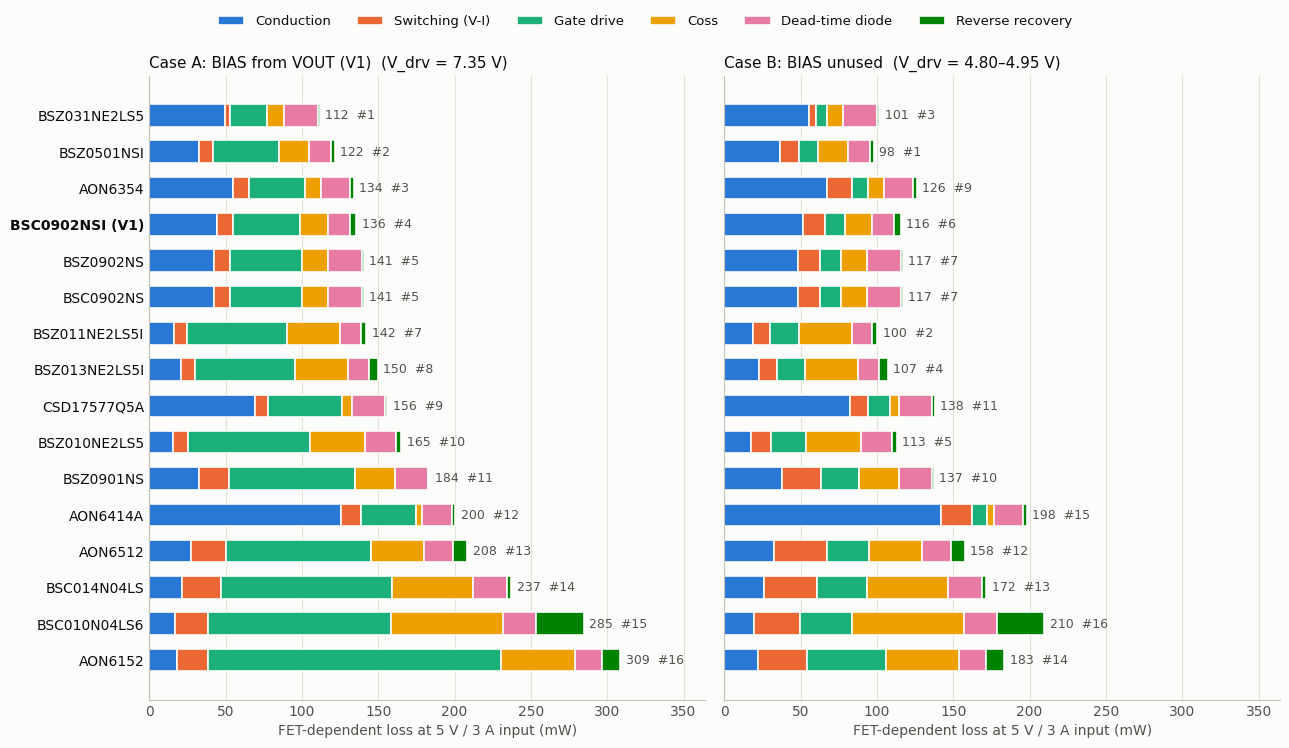

In [4]:
SURFACE, INK, INK_2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
TERM_COLORS = dict(zip(TERMS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']))  # categorical slots 1-6

ranked = res[res['Status'] == 'ranked']
order = ranked[ranked['Case'] == 'A'].sort_values('Total_mW')['Part'].tolist()[::-1]   # best at top
x_max = ranked['Total_mW'].max() * 1.18

fig, axes = plt.subplots(1, 2, figsize=(13, 7.5), sharey=True, facecolor=SURFACE)
for ax, (case, label) in zip(axes, CASES.items()):
    sub = ranked[ranked['Case'] == case].set_index('Part').loc[order]
    left = np.zeros(len(sub))
    for t in TERMS:
        ax.barh(sub.index, sub[t], left=left, height=0.62, color=TERM_COLORS[t],
                edgecolor=SURFACE, linewidth=1.2, label=t, zorder=2)
        left += sub[t].to_numpy()
    for y, (pn, r) in enumerate(sub.iterrows()):
        ax.text(r['Total_mW'] + x_max * 0.01, y, f"{r['Total_mW']:.0f}  #{int(r['Rank'])}",
                va='center', fontsize=9, color=INK_2)
    v_note = f"{IC.V_VCC_NOM} V" if case == 'A' else f"{sub['V_drv'].min():.2f}–{sub['V_drv'].max():.2f} V"
    ax.set_title(f"Case {case}: {label}  (V_drv = {v_note})", fontsize=11, color=INK, loc='left')
    ax.set_xlim(0, x_max)
    ax.set_xlabel('FET-dependent loss at 5 V / 3 A input (mW)', color=INK_2)
    ax.set_facecolor(SURFACE)
    ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
    ax.tick_params(colors=INK_2, length=0)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(AXIS)

axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([f"{pn} (V1)" if pn == cfg.ACTIVE_FET_ID else pn for pn in order], color=INK)
for lbl in axes[0].get_yticklabels():
    if lbl.get_text().endswith('(V1)'):
        lbl.set_fontweight('bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(TERMS), frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.5, 1.0), labelcolor=INK)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Sensitivity of the ranking

The largest modeling uncertainties are the R_DS(on) temperature rise (table values are 25 °C; AON6512 Figure 4, for example, shows ≈1.17× at 75 °C and ≈1.28× at 100 °C), the Q_rr scaling from the test current, and the C_oss figure reads (±20 %). Each is varied on its own and the rank recomputed.

In [5]:
SCEN = {
    'base':          dict(cond=1.0, rr=1.0, coss=1.0),
    'R_DS(on) x1.3': dict(cond=1.3, rr=1.0, coss=1.0),
    'Q_rr x0':       dict(cond=1.0, rr=0.0, coss=1.0),
    'Q_rr x2':       dict(cond=1.0, rr=2.0, coss=1.0),
    'Coss x0.8':     dict(cond=1.0, rr=1.0, coss=0.8),
}
for case, label in CASES.items():
    sub = ranked[ranked['Case'] == case].set_index('Part')
    out = {}
    for name, s in SCEN.items():
        tot = (s['cond'] * sub['Conduction'] + sub['Switching (V-I)'] + sub['Gate drive'] + s['coss'] * sub['Coss']
               + sub['Dead-time diode'] + s['rr'] * sub['Reverse recovery'])
        out[(name, 'mW')] = tot.round(1)
        out[(name, '#')] = tot.rank(method='min').astype(int)
    table = pd.DataFrame(out).sort_values(('base', 'mW'))
    print(f"=== Case {case}: {label} ===")
    print(table.to_string())
    print()

v1 = ranked[ranked['Part'] == cfg.ACTIVE_FET_ID].set_index('Case')
best = ranked.loc[ranked.groupby('Case')['Total_mW'].idxmin()].set_index('Case')
for case in CASES:
    gap = v1.loc[case, 'Total_mW'] - best.loc[case, 'Total_mW']
    print(f"Case {case}: V1 {cfg.ACTIVE_FET_ID} {v1.loc[case, 'Total_mW']:.1f} mW (#{int(v1.loc[case, 'Rank'])}) vs best "
          f"{best.loc[case, 'Part']} {best.loc[case, 'Total_mW']:.1f} mW: gap {gap:.1f} mW = {100 * gap * 1e-3 / (V_IN * I_IN):.2f} % of the 15 W input")

=== Case A: BIAS from VOUT (V1) ===
                base     R_DS(on) x1.3     Q_rr x0     Q_rr x2     Coss x0.8    
                  mW   #            mW   #      mW   #      mW   #        mW   #
Part                                                                            
BSZ031NE2LS5   111.6   1         126.5   1   110.3   1   112.9   1     109.4   1
BSZ0501NSI     121.5   2         131.3   2   119.2   2   123.8   2     117.6   2
AON6354        134.0   3         150.5   5   131.3   3   136.8   3     131.9   3
BSC0902NSI     135.6   4         149.0   4   131.5   4   139.6   4     132.0   4
BSZ0902NS      140.5   5         153.3   6   139.4   6   141.6   5     137.1   6
BSC0902NS      140.5   5         153.3   6   139.4   6   141.6   5     137.1   6
BSZ011NE2LS5I  142.0   7         146.8   3   138.7   5   145.2   7     135.0   5
BSZ013NE2LS5I  149.6   8         155.8   8   143.7   8   155.4   8     142.6   8
CSD17577Q5A    155.8   9         176.6  10   154.4   9   157.3   9     15

## Voltage margin and splitting parts by position

**Stress.** The input-side FETs (QH1, QL1) see VIN plus switch-node ringing. USB PD R3.0 V1.1 Table 7-19 allows a 20 V fixed supply 0.95–1.05 × PDO, plus ±0.5 V during and after a transition, so **21.5 V** at the receptacle; the project's own 10 % margin gives 22 V. Before any ringing, that is 86 % of a 25 V rating, 72 % of 30 V and 54 % of 40 V. For comparison, the LM5176 datasheet design example rates its input FETs at 83 % (60 V parts for a 50 V input). The output-side FETs (QH2, QL2) see 12 V, and the output TVS (notebook 05) clamps near 14–15 V. How much ringing V1 actually has at SW1 has not been measured.

**Loss by position.** At the Objective 1 point (boost), QH1 is held on and QL1 is off, so the input side only contributes QH1's conduction loss, I_L,rms² · R_DS(on). Every switching, gate, C_oss, dead-time and recovery term belongs to QL2 and QH2. So the two sides can use different parts, and a higher-voltage input side costs nothing at 5 V / 3 A as long as its R_DS(on) is low. The table below recombines the case-A terms per position. **Not covered:** in buck mode (15 V and 20 V PD inputs) QH1 and QL1 hard-switch, so the input-side part's gate charge, C_oss and Q_rr matter there. That operating point is not modeled in this notebook yet.

In [6]:
caseA = res[(res['Case'] == 'A') & (res['Status'] == 'ranked')].set_index('Part')

def qh1_conduction_mW(pn):
    return I_RMS**2 * rdson_at(pn, IC.V_VCC_NOM) * 1e3

split_rows = []
for out_pn in ['BSC0902NSI', 'BSZ0501NSI', 'BSZ031NE2LS5']:
    for in_pn in ['BSC0902NSI', 'BSZ0501NSI', 'BSC014N04LS', 'BSC010N04LS6', 'AON6152']:
        split_rows.append({
            'Output side (QL2, QH2)': out_pn,
            'Input side (QH1, QL1)': in_pn,
            'Input VDS (V)': fets.loc[in_pn, 'VDS_Max(V)'],
            'Input use @21.5 V (%)': round(100 * V_IN_PD_MAX / fets.loc[in_pn, 'VDS_Max(V)']),
            'QH1 conduction (mW)': round(qh1_conduction_mW(in_pn), 1),
            'Total, case A (mW)': round(caseA.loc[out_pn, 'Total_mW'] - qh1_conduction_mW(out_pn) + qh1_conduction_mW(in_pn), 1),
        })
split = pd.DataFrame(split_rows).sort_values('Total, case A (mW)')
print(split.to_string(index=False))
print(f"\nV1 (BSC0902NSI in all four positions): {caseA.loc[cfg.ACTIVE_FET_ID, 'Total_mW']:.1f} mW")

Output side (QL2, QH2) Input side (QH1, QL1)  Input VDS (V)  Input use @21.5 V (%)  QH1 conduction (mW)  Total, case A (mW)
          BSZ031NE2LS5          BSC010N04LS6             40                     54                  8.5                95.3
          BSZ031NE2LS5               AON6152             45                     48                  9.0                95.7
          BSZ031NE2LS5           BSC014N04LS             40                     54                 10.8                97.6
          BSZ031NE2LS5            BSZ0501NSI             30                     72                 16.2               103.0
          BSZ031NE2LS5            BSC0902NSI             30                     72                 22.3               109.1
            BSZ0501NSI          BSC010N04LS6             40                     54                  8.5               113.8
            BSZ0501NSI               AON6152             45                     48                  9.0               114.3
        

## BIAS wiring: VOUT vs unused, across the input range

For the V1 part only, the loss difference between the two BIAS wirings (A − B; positive means BIAS→VOUT loses more).

- **At 5 V:** taken from the full model above, where the two wirings give different gate voltages.
- **At VIN ≥ 7.5 V:** VCC is in regulation at 7.35 V either way (Figure 6-4), so R_DS(on) and Q_g are the same. Only the voltage that the VCC linear regulator draws the gate charge from differs, VOUT (12 V) or VIN: ΔP = 2·Q_g(7.35 V)·f_sw·(V_OUT − V_IN). Two FETs switch every cycle in both boost (QL2/QH2) and buck (QH1/QL1) mode.
- **Not included:** the controller's own operating current, whose split between VIN and BIAS the datasheet table does not give.

In [7]:
v1_pn = cfg.ACTIVE_FET_ID
qg_reg = qg_at(v1_pn, IC.V_VCC_NOM)
i_gate = 2 * qg_reg * F_SW
v1_rows = res[res['Part'] == v1_pn].set_index('Case')
bias_rows = [dict(V_IN=V_IN, mode='boost', delta_mW=v1_rows.loc['A', 'Total_mW'] - v1_rows.loc['B', 'Total_mW'],
                  basis='full model (different gate voltage)')]
for v in [9.0, 15.0, 20.0]:
    bias_rows.append(dict(V_IN=v, mode='boost' if v < V_OUT else 'buck', delta_mW=i_gate * (V_OUT - v) * 1e3,
                          basis='gate-charge supply voltage only'))
print(f"{v1_pn}: Q_g(7.35 V) = {qg_reg*1e9:.2f} nC -> gate-charge current {i_gate*1e3:.2f} mA")
print(pd.DataFrame(bias_rows).round(1).to_string(index=False))

BSC0902NSI: Q_g(7.35 V) = 18.31 nC -> gate-charge current 3.66 mA
 V_IN  mode  delta_mW                               basis
  5.0 boost      20.1 full model (different gate voltage)
  9.0 boost      11.0     gate-charge supply voltage only
 15.0  buck     -11.0     gate-charge supply voltage only
 20.0  buck     -29.3     gate-charge supply voltage only


## Price check (not part of Objective 1)

Objective 1 leaves part cost unconstrained; prices are recorded here for context and for Objective 2 (notebook 09). `Price_Ref_50_USD` is priced for a 50-board build: DigiKey cut tape at the highest break at or below 200 FETs, which is the 100-pc break (`data/README.md`). `Price_Build_USD` is JLCPCB at the 1+ break, the V1 order quantity. Four FETs per board. Loss is case A (V1 wiring).

In [8]:
priced = fets[fets['Price_Ref_50_USD'].notna() | fets['Price_Build_USD'].notna()].copy()
a = res[res['Case'] == 'A'].set_index('Part')
v1_ref, v1_build = fets.loc[v1_pn, 'Price_Ref_50_USD'], fets.loc[v1_pn, 'Price_Build_USD']
tbl = pd.DataFrame({
    'DigiKey 50-board ($/FET)': priced['Price_Ref_50_USD'],
    'DigiKey break (pcs)': priced['Price_Ref_Qty'],
    'JLCPCB 1+ ($/FET)': priced['Price_Build_USD'],
    'Board vs V1, DigiKey ($)': 4 * (priced['Price_Ref_50_USD'] - v1_ref),
    'Board vs V1, JLCPCB ($)': 4 * (priced['Price_Build_USD'] - v1_build),
    'FET loss case A (mW)': a.loc[priced.index, 'Total_mW'],
    'Loss vs V1 (mW)': a.loc[priced.index, 'Total_mW'] - a.loc[v1_pn, 'Total_mW'],
})
print(tbl.round(4).sort_values('FET loss case A (mW)').to_string())

# Scale check only: the 5 V / 3 A loss gap if it applied around the clock (it does not; see notebook 09)
gap_w = (a.loc[v1_pn, 'Total_mW'] - a.loc['BSZ0501NSI', 'Total_mW']) * 1e-3
usd_per_year = gap_w * cfg.HOURS_PER_YEAR / 1e3 * cfg.ELECTRICITY_USD_PER_KWH
print(f"\nBSZ0501NSI saves {gap_w*1e3:.1f} mW at 5 V / 3 A; even continuously that is ${usd_per_year:.3f}/yr of electricity "
      f"against ${4 * (fets.loc['BSZ0501NSI', 'Price_Ref_50_USD'] - v1_ref):.2f} more per board at 50-board DigiKey pricing "
      f"(${4 * (fets.loc['BSZ0501NSI', 'Price_Build_USD'] - v1_build):.2f} at JLCPCB 1+).")

             DigiKey 50-board ($/FET)  DigiKey break (pcs)  JLCPCB 1+ ($/FET)  Board vs V1, DigiKey ($)  Board vs V1, JLCPCB ($)  FET loss case A (mW)  Loss vs V1 (mW)
Part_Number                                                                                                                                                            
BSZ0501NSI                     0.9270                100.0             1.1133                    1.4872                   1.7124              121.5184         -14.0594
BSC0902NSI                     0.5552                100.0             0.6852                    0.0000                   0.0000              135.5777           0.0000
BSC0902NS                      0.6124                100.0             0.6787                    0.2288                  -0.0260              140.5485           4.9707

BSZ0501NSI saves 14.1 mW at 5 V / 3 A; even continuously that is $0.025/yr of electricity against $1.49 more per board at 50-board DigiKey pricing ($1.71 at JL

# Final Conclusions

**Chosen part (V1, as built): BSC0902NSI**, with BIAS tied to VOUT (case A). At the Objective 1 point its FET-dependent loss is 135.6 mW, #4 of 16 ranked parts. The best checked part is 24.0 mW lower (0.16 % of the 15 W input). BSZ0501NSI is 14.1 mW lower (0.09 %). That margin is real but small, within the 17–84 mW range by which the eight lower-loss (JLCPCB-unstocked) inductors in notebook 03 beat the V1 inductor.

Why it is not the best: in case A the largest term is gate drive (44 mW for BSC0902NSI). QL2 and QH2 are recharged every cycle from the 12 V output through the VCC linear regulator. At 3 A, the lowest-R_DS(on) parts (BSZ011NE2LS5I, BSC014N04LS, BSC010N04LS6) lose more in gate drive and C_oss than they save in conduction. BSC0902NSI already has the integrated Schottky-like diode (V_SD 0.54 V vs 0.83 V), which is why it beats BSC0902NS by 5.0 mW on nearly identical R_DS(on) and Q_g. That makes BSC0902NSI the better of the two, and their prices are within a few cents: $0.6852 vs $0.6787 at JLCPCB (1+), $0.5552 vs $0.6124 at DigiKey (50-board pricing).

**Why V1 uses BSC0902NSI.** The V1 decision was to use a **40 V** part, for margin on the 20 V PD input (designer, confirmed 2026-09-14). The selection notebook, `archive/notebooks_original/2_Buck_Boost_Mosfets.ipynb` (committed 2026-02-03), ranks parts by loss within VDS groups and ends with `mosfet_choice = "BSC0902NS"`. Its part table was drafted with AI help and not checked against datasheets at the time, and it listed BSC0902NS as 40 V. In that chart:
- **"40 V" group:** BSC0902NS (0.17 W) was the lowest-loss part after EPC2024, a GaN part the LM5176 cannot drive.
- **30 V group:** BSZ0501NSI was 0.15 W, already about 14 mW lower, but it was in the 30 V group and so excluded by the 40 V requirement.

BSC0902NS is actually a 30 V part. The error was not found until the datasheet check on 2026-09-14. The board was then built with BSC0902NSI (the designer recalls a lower JLCPCB price at the time), also 30 V. So **V1 does not meet its own 40 V intent**: it has the same 30 V rating as BSZ0501NSI. Whether 30 V is acceptable is now a question for measurement (see Voltage margin below).

Judged today, BSC0902NSI is a reasonable V1 part but not the Objective 1 optimum, because Objective 1 ignores cost:
- **Loss:** 14.1 mW (0.09 %) behind BSZ0501NSI.
- **Cost:** $1.49 per board cheaper at 50-board DigiKey pricing, $1.71 at JLCPCB.
- **Other:** it has the integrated diode and is listed at JLCPCB.

**V2 candidate: BSZ0501NSI** (OptiMOS 5, 30 V, PQFN 3.3 × 3.3):
- 121.5 mW (#2) in case A and 97.9 mW (#1) in case B.
- #1–2 under every sensitivity variant (R_DS(on) ×1.3, Q_rr ×0 / ×2, C_oss ×0.8).
- Its 30 V rating gives the same input-side margin as V1.
- It is a different footprint from V1's SuperSO8 (5 × 6 mm), so adopting it is a layout change.
- It costs $1.49 more per board at 50-board DigiKey pricing ($1.71 at JLCPCB 1+). The case for it is 14 mW more fan power at the 5 V corner, not electricity: even around the clock that gap is worth $0.025/yr.

**BIAS wiring.** For the V1 part:
- **At 5 V in:** tying BIAS to VOUT costs 20 mW, because the gate charge comes from 12 V instead of 5 V. The lower R_DS(on) at 7.35 V does not make up for it at 3 A.
- **At 9 V:** it costs 11 mW.
- **At 15 V and 20 V:** it saves 11 mW and 29 mW, because the regulator then drops from 12 V instead of from VIN.

So neither wiring is better everywhere; it depends on which input voltage the board mostly runs from. That belongs to Objective 2 (notebook 09). Two things not in these numbers favour BIAS→VOUT:
- VCC does not sag with the input, which the LM5176 datasheet asks for at low VIN to keep the MOSFETs fully enhanced.
- It is TI's recommendation for VOUT > 8.5 V.

One requirement comes with it: the datasheet calls for a series blocking diode between the input rail and the VIN pin when BIAS is used, so VCC cannot back-feed VIN through the regulator's body diode when VIN < VCC, which is the case at a 5 V input. **V1 as built omitted this diode.** One board has been reworked with it, and the omission was part of how the UVLO/pre-bias restart problem was found (designer, 2026-09-14).

**Voltage margin.** At 21.5 V, the USB PD maximum on a 20 V contract, a 30 V input-side part runs at 72 % of its rating before switch-node ringing, and a 25 V part at 86 %. That is tighter than the LM5176 datasheet example (83 %), so 25 V parts are ruled out for the input side. Whether 30 V is enough depends on the SW1 overshoot at 20 V input, which has not been measured.

The split-by-position table shows the extra margin is free at the Objective 1 point: in boost mode the input side only conducts. For example:
- **BSC010N04LS6 (40 V) input side + BSC0902NSI output side:** 121.8 mW, as low as all-BSZ0501NSI (121.5 mW) and 13.8 mW below V1.
- **BSC010N04LS6 input side + BSZ0501NSI output side:** 113.8 mW.
- **Caveat:** these 40 V parts have high Q_g, Q_oss and Q_rr, which only matter when QH1/QL1 switch in buck mode at 15–20 V input. That operating point is not modeled yet, so no split is recommended until it is.

Other results worth recording:
- **BSZ031NE2LS5:** #1 in case A (111.6 mW), #2–4 in case B. It is rated 25 V, so 86 % of rating at 21.5 V before ringing: output side only (QL2/QH2 see 12 V, TVS-clamped near 14–15 V). As an output-side part it gives the lowest split totals (95–109 mW). The same limit applies to BSZ011NE2LS5I, BSZ013NE2LS5I and BSZ010NE2LS5.

Not ranked:
- **EPC2024** (V_GS max 6 V) and **GS61008P** (+7 V): below the LM5176's 7.88 V VCC maximum, so the controller cannot drive them directly.
- **ISC230N10NM6:** normal-level. R_DS(on) is specified only at 8 V and 10 V, and its 4.8 V plateau is at the 5 V input voltage, where the LM5176 datasheet requires the plateau to be below minimum VIN.
- **TPH1R104PB:** its datasheet gives no Q_rr. Even without that term it is already at ≈255 mW in case A, and it is not characterized below 6 V gate drive.

What these numbers rest on:
- **Part data:** datasheet-table typicals at 25 °C. The source revision is in `mosfets.csv` (`Datasheet_Rev`).
- **Interpolation:** the R_DS(on) fit reads 0–8 % high against three datasheet curves, so it errs conservative. Q_g is linear above the plateau.
- **Figure reads:** the plateau voltage for five parts, C_oss integrals for the four AOS parts and TPH1R104PB, and TPH1R104PB's gate charge and V_SD come from datasheet figures, with the uncertainty listed in `data/mosfet_figure_reads.csv`.
- **Test conditions:** Q_rr at 3 A is scaled from test currents of 4–50 A, and V_SD is taken at the datasheet's 1–50 A test current.
- **Prices:** hand-read on 2026-09-14. They exist only for BSC0902NSI, BSC0902NS and BSZ0501NSI.

Open items:
1. **Bench efficiency at 5 V / 3 A, BSC0902NSI vs BSZ0501NSI.** The predicted 14 mW difference is small enough that a layout change should wait for a measurement.
2. **SW1 overshoot at 20 V input, full load (measurement).** It decides whether 30 V is enough on the input side. Also capture VIN on hot-plug: the board has no input TVS.
3. **Buck-mode FET losses at 15 V and 20 V input.** Needed before choosing a separate input-side part (see the split-by-position section).
4. **Remaining prices.** Reference prices (50-board basis) and build prices are still blank for the other 17 MOSFETs.

In [9]:
mosfet_choice = "BSC0902NSI"   # V1 board part (as built)
v2_candidate = "BSZ0501NSI"    # best-supported alternative at the Objective 1 point